# Men's College Basketball Game Predictor
Logistic regression model that predicts the winner of a head-to-head matchup using team season stats.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# i personally like to use my brand colors, but you don't have to stick to this!
brand_colors = ['#ff2f93', '#0f56f5', '#8a2be2', '#ff6700', '#2ecc71']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=brand_colors)
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

In [38]:
# the csv has repeated header rows every ~20 teams, plus a multi-level header
# we'll skip the first row (group headers) and use the second row as columns
df = pd.read_csv('mens_basketball_school_stats.csv', header=1)

# drop the repeated header rows and any blank separator rows
df = df[df['Rk'].apply(lambda x: str(x).strip().isdigit())].copy()
df = df.reset_index(drop=True)

# drop the empty separator columns
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

df.head()

,Rk,School,G,W,L,W-L%,SRS,SOS,W.1,L.1,...,FT,FTA,FT%,ORB,TRB,AST,STL,BLK,TOV,PF
0,1,Abilene Christian,29,13,16,.448,-5.85,-0.77,5,11,...,445,626,.711,341,933,395,288,82,414,593
1,2,Air Force,30,3,27,.100,-13.18,4.72,0,19,...,350,546,.641,213,878,377,164,72,446,531
2,3,Akron,30,25,5,.833,9.30,-2.98,16,1,...,414,535,.774,345,1142,569,230,91,332,474
3,4,Alabama,30,22,8,.733,23.04,14.61,12,5,...,565,733,.771,364,1222,490,195,152,300,560
4,5,Alabama A&M,30,17,13,.567,-12.42,-10.05,10,7,...,538,722,.745,280,1025,342,178,87,345,538


In [39]:
# convert everything that should be numeric
num_cols = [c for c in df.columns if c not in ['School']]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.shape

(365, 33)

## Feature Engineering

In [40]:
# normalize totals to per-game so teams that played more games don't get inflated
per_game_cols = ['FG', 'FGA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF']

for col in per_game_cols:
    df[f'{col}_pg'] = df[col] / df['G']

# per-game points
df['pts_pg'] = df['Tm.'] / df['G']
df['opp_pts_pg'] = df['Opp.'] / df['G']

# point differential per game is a strong signal
df['pt_diff_pg'] = df['pts_pg'] - df['opp_pts_pg']

df[['School', 'G', 'W-L%', 'SRS', 'pts_pg', 'opp_pts_pg', 'pt_diff_pg']].head(10)



,School,G,W-L%,SRS,pts_pg,opp_pts_pg,pt_diff_pg
0,Abilene Christian,29,0.448,-5.85,70.965517,71.724138,-0.758621
1,Air Force,30,0.100,-13.18,62.166667,80.066667,-17.900000
2,Akron,30,0.833,9.30,89.433333,74.333333,15.100000
3,Alabama,30,0.733,23.04,92.000000,83.566667,8.433333
4,Alabama A&M,30,0.567,-12.42,71.766667,71.900000,-0.133333
5,Alabama State,30,0.333,-13.39,73.766667,77.700000,-3.933333
6,Albany (NY),31,0.355,-13.56,71.838710,72.612903,-0.774194
7,Alcorn State,29,0.276,-19.47,67.586207,81.137931,-13.551724
8,American,31,0.516,-6.75,74.645161,71.225806,3.419355
9,Appalachian State,31,0.613,-3.00,72.000000,65.419355,6.580645


## Quick EDA

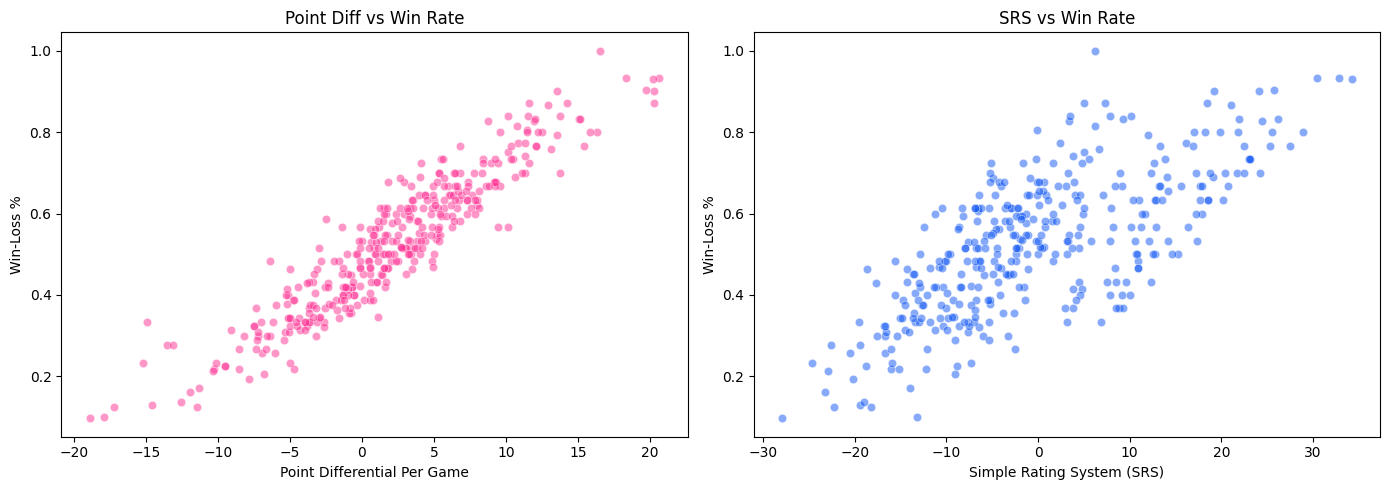

In [41]:
# let's see how point differential relates to winning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['pt_diff_pg'], df['W-L%'], alpha=0.5, color='#ff2f93', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Point Differential Per Game')
axes[0].set_ylabel('Win-Loss %')
axes[0].set_title('Point Diff vs Win Rate')

axes[1].scatter(df['SRS'], df['W-L%'], alpha=0.5, color='#0f56f5', edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Simple Rating System (SRS)')
axes[1].set_ylabel('Win-Loss %')
axes[1].set_title('SRS vs Win Rate')

plt.tight_layout()
plt.show()

In [42]:
# features we'll use for matchups — all per-game or rate stats
feature_cols = [
    'W-L%', 'SRS', 'SOS',
    'FG%', '3P%', 'FT%',
    'FG_pg', 'FGA_pg', '3P_pg', '3PA_pg', 'FT_pg', 'FTA_pg',
    'ORB_pg', 'TRB_pg', 'AST_pg', 'STL_pg', 'BLK_pg', 'TOV_pg', 'PF_pg',
    'pts_pg', 'opp_pts_pg', 'pt_diff_pg'
]

# quick check for nulls
df[feature_cols].isnull().sum()[df[feature_cols].isnull().sum() > 0]

Series([], dtype: int64)

## Build Matchup Dataset

In [43]:
# create pairwise matchups: for each pair of teams, team A vs team B
# label = 1 if team A wins (higher W-L%), 0 otherwise
# features = difference in stats (team_a - team_b)

np.random.seed(42)
teams = df.set_index('School')[feature_cols]

matchup_rows = []
team_names = teams.index.tolist()

for i in range(len(team_names)):
    for j in range(i + 1, len(team_names)):
        a = teams.loc[team_names[i]]
        b = teams.loc[team_names[j]]
        diff = a - b

        # who would win? we use SRS as our ground truth — it's the best
        # single predictor of game outcomes in college basketball
        label = 1 if a['SRS'] > b['SRS'] else 0

        row = diff.to_dict()
        row['label'] = label
        row['team_a'] = team_names[i]
        row['team_b'] = team_names[j]
        matchup_rows.append(row)

        # also add the reverse matchup for symmetry
        rev_row = (-diff).to_dict()
        rev_row['label'] = 1 - label
        rev_row['team_a'] = team_names[j]
        rev_row['team_b'] = team_names[i]
        matchup_rows.append(rev_row)

matchups = pd.DataFrame(matchup_rows)
print(f"total matchups: {matchups.shape[0]:,}")
matchups.head()

total matchups: 132,860


,W-L%,SRS,SOS,FG%,3P%,FT%,FG_pg,FGA_pg,3P_pg,3PA_pg,...,STL_pg,BLK_pg,TOV_pg,PF_pg,pts_pg,opp_pts_pg,pt_diff_pg,label,team_a,team_b
0,0.348,7.33,-5.49,0.011,0.007,0.070,2.994253,5.619540,-0.867816,-3.114943,...,4.464368,0.427586,-0.590805,2.748276,8.798851,-8.342529,17.141379,1,Abilene Christian,Air Force
1,-0.348,-7.33,5.49,-0.011,-0.007,-0.070,-2.994253,-5.619540,0.867816,3.114943,...,-4.464368,-0.427586,0.590805,-2.748276,-8.798851,8.342529,-17.141379,0,Air Force,Abilene Christian
2,-0.385,-15.15,2.21,-0.065,-0.054,-0.063,-7.539080,-7.580460,-4.934483,-10.448276,...,2.264368,-0.205747,3.209195,4.648276,-18.467816,-2.609195,-15.858621,0,Abilene Christian,Akron
3,0.385,15.15,-2.21,0.065,0.054,0.063,7.539080,7.580460,4.934483,10.448276,...,-2.264368,0.205747,-3.209195,-4.648276,18.467816,2.609195,15.858621,1,Akron,Abilene Christian
4,-0.285,-28.89,-15.38,-0.018,-0.040,-0.060,-5.272414,-9.247126,-7.001149,-17.281609,...,3.431034,-2.239080,4.275862,1.781609,-21.034483,-11.842529,-9.191954,0,Abilene Christian,Alabama


In [44]:
# SRS is what we used to create labels, so we can't use it as a feature
# also drop W-L% since it's too directly correlated with outcome
train_features = [c for c in feature_cols if c not in ['SRS', 'W-L%', 'SOS']]

X = matchups[train_features]
y = matchups['label']

X.shape

(132860, 19)

## Model Training

In [45]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features — logistic regression cares about this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"train: {X_train_scaled.shape[0]:,} matchups")
print(f"test:  {X_test_scaled.shape[0]:,} matchups")

train: 106,288 matchups
test:  26,572 matchups


In [46]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"train accuracy: {train_acc:.3f}")
print(f"test accuracy:  {test_acc:.3f}")

train accuracy: 0.815
test accuracy:  0.817


## Evaluation

In [47]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Team B wins', 'Team A wins']))

              precision    recall  f1-score   support

 Team B wins       0.82      0.82      0.82     13318
 Team A wins       0.82      0.82      0.82     13254

    accuracy                           0.82     26572
   macro avg       0.82      0.82      0.82     26572
weighted avg       0.82      0.82      0.82     26572



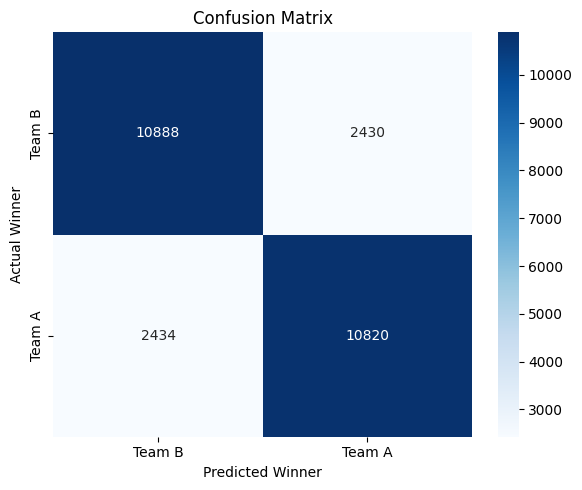

In [48]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Team B', 'Team A'], yticklabels=['Team B', 'Team A'], ax=ax)
ax.set_xlabel('Predicted Winner')
ax.set_ylabel('Actual Winner')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

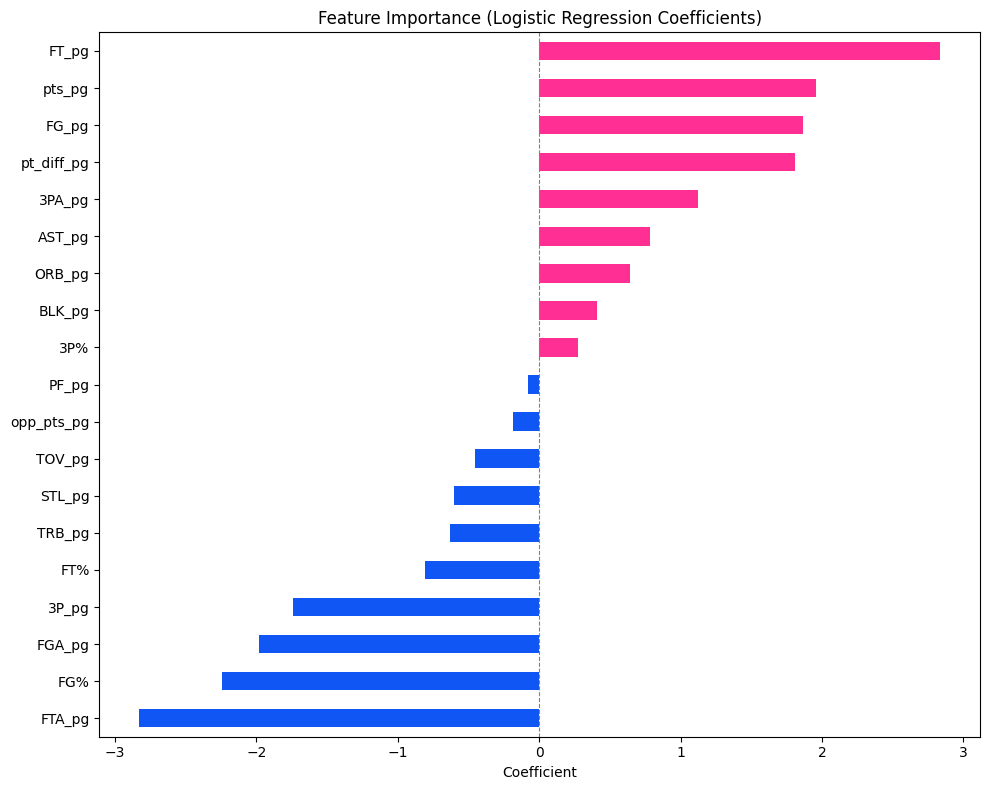

In [49]:
# which stats matter most for predicting the winner?
coefs = pd.Series(model.coef_[0], index=train_features).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
coefs.plot(kind='barh', color=['#0f56f5' if v < 0 else '#ff2f93' for v in coefs], ax=ax)
ax.set_xlabel('Coefficient')
ax.set_title('Feature Importance (Logistic Regression Coefficients)')
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

In [50]:
def predict_winner(team_a_name, team_b_name):
    """plug in two school names and get a prediction"""
    a = teams.loc[team_a_name][train_features]
    b = teams.loc[team_b_name][train_features]
    diff = (a - b).values.reshape(1, -1)
    diff_scaled = scaler.transform(diff)

    prob = model.predict_proba(diff_scaled)[0]
    winner = team_a_name if prob[1] > 0.5 else team_b_name
    confidence = max(prob)

    print(f"{team_a_name} vs {team_b_name}")
    print(f"predicted winner: {winner} ({confidence:.1%} confidence)")
    return winner, confidence

# try it out
predict_winner('Duke', 'North Carolina')
predict_winner('Florida', 'Houston')

Duke vs North Carolina
predicted winner: Duke (85.9% confidence)
Florida vs Houston
predicted winner: Florida (73.6% confidence)


('Florida', 0.7363807197320748)

## March Madness 2026 — Monte Carlo Simulation
Now let's use this model to simulate the entire NCAA tournament bracket 10,000 times and see who's most likely to cut down the nets.

In [51]:
from collections import defaultdict

# map bracket names to Sports Reference names in the CSV
NAME_MAP = {
    "St. John's": "St. John's (NY)",
    "UConn": "Connecticut",
    "Cal Baptist": "California Baptist",
    "McNeese": "McNeese State",
    "Penn": "Pennsylvania",
    "Saint Mary's": "Saint Mary's (CA)",
    "Miami": "Miami (FL)",
    "Queens": "Queens (NC)",
    "Long Island": "Long Island University",
    "VCU": "Virginia Commonwealth",
    "BYU": "Brigham Young",
    "Miami (OH)": "Miami (OH)",
    "Howard": "Howard",
    "Prairie View": "Prairie View",
    "Hawaii": "Hawaii",
}

def resolve_name(name):
    """Convert bracket name to Sports Reference CSV name."""
    return NAME_MAP.get(name, name)

# ============================================================
# 2026 BRACKET — First Round matchups by region (FINALIZED)
# First Four complete: Prairie View, Miami (OH), Howard, Texas won
# Each tuple: (higher_seed_num, higher_seed_team, lower_seed_num, lower_seed_team)
# ============================================================

BRACKET = {
    "East": [
        (1, "Duke", 16, "Siena"),
        (8, "Ohio State", 9, "TCU"),
        (5, "St. John's", 12, "Northern Iowa"),
        (4, "Kansas", 13, "Cal Baptist"),
        (6, "Louisville", 11, "South Florida"),
        (3, "Michigan State", 14, "North Dakota State"),
        (7, "UCLA", 10, "UCF"),
        (2, "UConn", 15, "Furman"),
    ],
    "South": [
        (1, "Florida", 16, "Prairie View"),
        (8, "Clemson", 9, "Iowa"),
        (5, "Vanderbilt", 12, "McNeese"),
        (4, "Nebraska", 13, "Troy"),
        (6, "North Carolina", 11, "VCU"),
        (3, "Illinois", 14, "Penn"),
        (7, "Saint Mary's", 10, "Texas A&M"),
        (2, "Houston", 15, "Idaho"),
    ],
    "West": [
        (1, "Arizona", 16, "Long Island"),
        (8, "Villanova", 9, "Utah State"),
        (5, "Wisconsin", 12, "High Point"),
        (4, "Arkansas", 13, "Hawaii"),
        (6, "BYU", 11, "Texas"),
        (3, "Gonzaga", 14, "Kennesaw State"),
        (7, "Miami", 10, "Missouri"),
        (2, "Purdue", 15, "Queens"),
    ],
    "Midwest": [
        (1, "Michigan", 16, "Howard"),
        (8, "Georgia", 9, "Saint Louis"),
        (5, "Texas Tech", 12, "Akron"),
        (4, "Alabama", 13, "Hofstra"),
        (6, "Tennessee", 11, "Miami (OH)"),
        (3, "Virginia", 14, "Wright State"),
        (7, "Kentucky", 10, "Santa Clara"),
        (2, "Iowa State", 15, "Tennessee State"),
    ],
}

# verify all teams exist in our stats
missing = []
for region, matchups in BRACKET.items():
    for seed_a, team_a, seed_b, team_b in matchups:
        for t in [team_a, team_b]:
            resolved = resolve_name(t)
            if resolved not in teams.index:
                missing.append((region, t, resolved))

if missing:
    print("WARNING — teams not found in stats CSV:")
    for region, orig, resolved in missing:
        print(f"  {region}: {orig} -> {resolved}")
else:
    print("All 64 teams found in stats CSV")

All 64 teams found in stats CSV


### Simulation Engine

In [52]:
def get_win_probability(team_a, team_b):
    """Get probability that team_a beats team_b using our trained model."""
    a = teams.loc[resolve_name(team_a)][train_features]
    b = teams.loc[resolve_name(team_b)][train_features]
    diff = (a - b).values.reshape(1, -1)
    diff_scaled = scaler.transform(diff)
    prob_a_wins = model.predict_proba(diff_scaled)[0][1]
    return prob_a_wins


def simulate_game(team_a, team_b):
    """Simulate a single game. Returns the winner."""
    prob_a = get_win_probability(team_a, team_b)
    return team_a if np.random.random() < prob_a else team_b


def simulate_region(matchups):
    """Simulate one region through all 4 rounds (R64 -> Elite 8)."""
    results = {'R64': [], 'R32': [], 'S16': [], 'E8': []}

    # Round of 64
    r64_winners = []
    for seed_a, team_a, seed_b, team_b in matchups:
        winner = simulate_game(team_a, team_b)
        r64_winners.append(winner)
        results['R64'].append(winner)

    # Round of 32
    r32_winners = []
    for i in range(0, 8, 2):
        winner = simulate_game(r64_winners[i], r64_winners[i + 1])
        r32_winners.append(winner)
        results['R32'].append(winner)

    # Sweet 16
    s16_winners = []
    for i in range(0, 4, 2):
        winner = simulate_game(r32_winners[i], r32_winners[i + 1])
        s16_winners.append(winner)
        results['S16'].append(winner)

    # Elite 8
    champion = simulate_game(s16_winners[0], s16_winners[1])
    results['E8'].append(champion)

    return champion, results


def simulate_tournament():
    """Simulate the entire tournament once."""
    all_results = defaultdict(list)
    regional_champs = {}

    for region_name, matchups in BRACKET.items():
        champ, region_results = simulate_region(matchups)
        regional_champs[region_name] = champ
        for round_name, winners in region_results.items():
            all_results[round_name].extend(winners)

    # Final Four: East vs South, West vs Midwest
    ff1 = simulate_game(regional_champs['East'], regional_champs['South'])
    ff2 = simulate_game(regional_champs['West'], regional_champs['Midwest'])
    all_results['F4'] = [ff1, ff2]

    # Championship
    champion = simulate_game(ff1, ff2)
    all_results['Championship'] = [champion]

    return all_results, champion


print("Simulation engine ready")

Simulation engine ready


### Run 10,000 Simulations

In [53]:
NUM_SIMS = 10_000
np.random.seed(42)

# track how far each team advances
round_labels = ['R64', 'R32', 'S16', 'E8', 'F4', 'Championship']
counts = defaultdict(lambda: {r: 0 for r in round_labels})

for sim in range(NUM_SIMS):
    if (sim + 1) % 2000 == 0:
        print(f"  {sim + 1:,}/{NUM_SIMS:,} simulations...")

    results, champion = simulate_tournament()

    for round_name in round_labels:
        for team in results.get(round_name, []):
            counts[team][round_name] += 1

print(f"\nDone! {NUM_SIMS:,} simulations complete.")

  2,000/10,000 simulations...
  4,000/10,000 simulations...
  6,000/10,000 simulations...
  8,000/10,000 simulations...
  10,000/10,000 simulations...

Done! 10,000 simulations complete.


### Results — Who Wins the Tournament?

In [54]:
# build results dataframe
prob_data = []
for team, team_counts in counts.items():
    row = {'Team': team}
    for r in round_labels:
        row[r] = team_counts[r] / NUM_SIMS
    prob_data.append(row)

prob_df = pd.DataFrame(prob_data)
prob_df = prob_df.sort_values('Championship', ascending=False).reset_index(drop=True)

# format as percentages for display
display_df = prob_df.copy()
for r in round_labels:
    display_df[r] = (display_df[r] * 100).round(1).astype(str) + '%'

display_df.columns = ['Team', 'Rd of 64', 'Rd of 32', 'Sweet 16', 'Elite 8', 'Final Four', 'Champion']
print("Top 20 teams by championship probability:\n")
display_df.head(20)

Top 20 teams by championship probability:



,Team,Rd of 64,Rd of 32,Sweet 16,Elite 8,Final Four,Champion
0,Michigan,98.6%,90.1%,84.8%,78.5%,66.1%,50.2%
1,Illinois,99.6%,93.8%,80.5%,57.5%,45.4%,21.9%
2,Florida,99.1%,92.5%,70.9%,30.5%,19.7%,6.7%
3,Duke,97.4%,90.3%,65.9%,42.9%,15.7%,4.5%
4,High Point,90.8%,61.7%,38.9%,25.4%,8.2%,4.0%
5,Arizona,99.3%,88.3%,42.4%,24.2%,6.6%,2.8%
6,Gonzaga,92.3%,85.3%,55.0%,25.8%,6.7%,2.6%
7,UConn,93.4%,81.1%,46.3%,22.1%,6.1%,1.3%
8,Virginia,93.0%,68.5%,51.0%,9.2%,3.8%,1.2%
9,Purdue,94.5%,82.5%,39.3%,15.2%,3.1%,1.0%


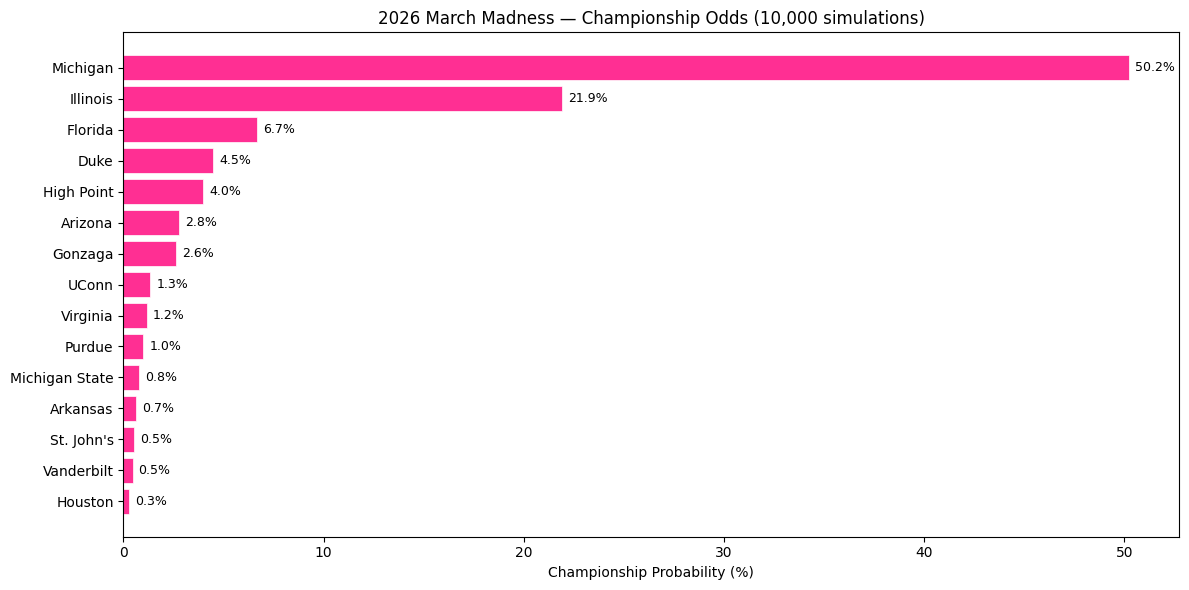

In [55]:
# championship odds bar chart
top_n = 15
top = prob_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(top_n), top['Championship'] * 100, color='#ff2f93', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['Team'])
ax.invert_yaxis()
ax.set_xlabel('Championship Probability (%)')
ax.set_title(f'2026 March Madness — Championship Odds ({NUM_SIMS:,} simulations)')

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{top.iloc[i]["Championship"] * 100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()